# Task 1 – Baseline Authentication Test

Test system effectiveness on ≥500 samples from enrolled speakers.
Balanced genuine (correct authentication) and impostor (impersonation) trials.

**Metrics reported:**
- EER – Equal Error Rate
- FAR – False Accept Rate (at EER threshold)
- FRR – False Reject Rate (at EER threshold)
- TAR – True Accept Rate = 1 − FRR
- ROC curve
- Score distribution plot

**Prerequisites:**
1. `data/enrollment/` and `data/test/` populated (via `download_data.py`)
2. Speakers enrolled in ChromaDB (via `enroll.py`)
3. Model cached in `models/ecapa/` (auto-downloaded on first run)

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Add src/ to path so we can import project modules
SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import interp1d

from config import cfg
from embeddings import load_model, get_embedding
from database import get_collection, list_enrolled
from threshold import (
    build_trial_scores,
    compute_eer,
    compute_metrics_at_threshold,
    save_plots,
)

RESULTS_DIR = cfg.paths.results_dir
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = cfg.dataset.random_seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: D:\pwr\biometria\lab\voice\results


## 1. Load model and database

In [2]:
print("Loading ECAPA-TDNN model...")
model = load_model()

collection = get_collection()
enrolled_ids = list_enrolled(collection)
print(f"Enrolled speakers: {len(enrolled_ids)}")

if len(enrolled_ids) == 0:
    raise RuntimeError("No speakers enrolled. Run src/enroll.py first.")

Loading ECAPA-TDNN model...


d:\pwr\biometria\venv\Lib\site-packages\speechbrain\utils\parameter_transfer.py:234: UserWarning: Requested Pretrainer collection using symlinks on Windows. This might not work; see `LocalStrategy` documentation. Consider unsetting `collect_in` in Pretrainer to avoid symlinking altogether.
  warnings.warn(
Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Enrolled speakers: 140


## 2. Build trial pairs and compute scores

- **Genuine trials**: test utterances from speaker X vs. X's enrolled profile  
- **Impostor trials**: test utterances from speaker X vs. Y's enrolled profile  

Target: ≥500 trials total, balanced 50/50.

In [3]:
# Adjust n_impostors_per_genuine to hit the ≥500 trial target.
# With 100 speakers × 50 genuine each = 5000 genuine → n_impostors=1 gives 5000 impostor too.
# Reduce max_genuine_per_speaker if you want a faster run.
N_IMPOSTORS_PER_GENUINE = 1
MAX_GENUINE_PER_SPEAKER = 50

genuine_scores, impostor_scores = build_trial_scores(
    model,
    collection,
    n_impostors_per_genuine=N_IMPOSTORS_PER_GENUINE,
    max_genuine_per_speaker=MAX_GENUINE_PER_SPEAKER,
)

print(f"\nGenuine  trials: {len(genuine_scores):>6}")
print(f"Impostor trials: {len(impostor_scores):>6}")
print(f"Total trials:    {len(genuine_scores) + len(impostor_scores):>6}")

assert len(genuine_scores) + len(impostor_scores) >= 500, \
    "Need at least 500 trials total. Increase MAX_GENUINE_PER_SPEAKER or add more speakers."

Computing scores for 140 speakers...
  id10270: 10 genuine, 10 impostor
  id10271: 10 genuine, 10 impostor
  id10272: 10 genuine, 10 impostor
  id10273: 10 genuine, 10 impostor
  id10274: 10 genuine, 10 impostor
  id10275: 10 genuine, 10 impostor
  id10276: 10 genuine, 10 impostor
  id10277: 10 genuine, 10 impostor
  id10278: 10 genuine, 10 impostor
  id10279: 10 genuine, 10 impostor
  id10280: 10 genuine, 10 impostor
  id10281: 10 genuine, 10 impostor
  id10282: 10 genuine, 10 impostor
  id10283: 10 genuine, 10 impostor
  id10284: 10 genuine, 10 impostor
  id10285: 10 genuine, 10 impostor
  id10286: 10 genuine, 10 impostor
  id10287: 10 genuine, 10 impostor
  id10288: 10 genuine, 10 impostor
  id10289: 10 genuine, 10 impostor
  id10290: 10 genuine, 10 impostor
  id10291: 10 genuine, 10 impostor
  id10292: 10 genuine, 10 impostor
  id10293: 10 genuine, 10 impostor
  id10294: 10 genuine, 10 impostor
  id10295: 10 genuine, 10 impostor
  id10296: 10 genuine, 10 impostor
  id10297: 10 genu

## 3. Score statistics

In [4]:
print(f"{'':20s} {'Genuine':>10} {'Impostor':>10}")
print("-" * 42)
print(f"{'Mean':20s} {genuine_scores.mean():>10.4f} {impostor_scores.mean():>10.4f}")
print(f"{'Std':20s} {genuine_scores.std():>10.4f} {impostor_scores.std():>10.4f}")
print(f"{'Min':20s} {genuine_scores.min():>10.4f} {impostor_scores.min():>10.4f}")
print(f"{'Max':20s} {genuine_scores.max():>10.4f} {impostor_scores.max():>10.4f}")

                        Genuine   Impostor
------------------------------------------
Mean                     0.8697     0.0583
Std                      0.0864     0.1023
Min                      0.3923    -0.2251
Max                      0.9687     0.4135


## 4. EER and threshold

In [5]:
eer, eer_threshold = compute_eer(genuine_scores, impostor_scores)
metrics = compute_metrics_at_threshold(genuine_scores, impostor_scores, eer_threshold)

print("─" * 48)
print(f"  EER            = {eer * 100:.2f}%")
print(f"  Threshold      = {eer_threshold:.6f}")
print(f"  FAR            = {metrics['far'] * 100:.2f}%")
print(f"  FRR            = {metrics['frr'] * 100:.2f}%")
print(f"  TAR            = {metrics['tar'] * 100:.2f}%")
print(f"  Accuracy       = {metrics['accuracy'] * 100:.2f}%")
print("─" * 48)

# Also show metrics at the threshold stored in config.toml
config_thr = cfg.auth.threshold
config_metrics = compute_metrics_at_threshold(genuine_scores, impostor_scores, config_thr)
print(f"\nAt config threshold ({config_thr:.4f}):")
print(f"  FAR = {config_metrics['far']*100:.2f}%  "
      f"FRR = {config_metrics['frr']*100:.2f}%  "
      f"Accuracy = {config_metrics['accuracy']*100:.2f}%")

────────────────────────────────────────────────
  EER            = 0.11%
  Threshold      = 0.396871
  FAR            = 0.14%
  FRR            = 0.07%
  TAR            = 99.93%
  Accuracy       = 99.89%
────────────────────────────────────────────────

At config threshold (0.2500):
  FAR = 4.57%  FRR = 0.00%  Accuracy = 97.71%


## 5. Score distribution plot

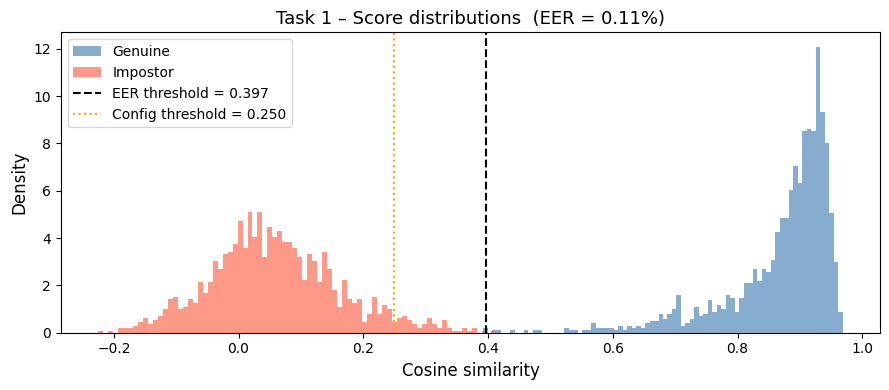

Saved: D:\pwr\biometria\lab\voice\results\task1_score_distributions.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(genuine_scores,  bins=80, alpha=0.65, label="Genuine",  color="steelblue",  density=True)
ax.hist(impostor_scores, bins=80, alpha=0.65, label="Impostor", color="tomato",     density=True)

ax.axvline(eer_threshold, color="black",  linestyle="--", linewidth=1.5,
           label=f"EER threshold = {eer_threshold:.3f}")
ax.axvline(config_thr,   color="orange", linestyle=":",  linewidth=1.5,
           label=f"Config threshold = {config_thr:.3f}")

ax.set_xlabel("Cosine similarity", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Task 1 – Score distributions  (EER = {eer*100:.2f}%)", fontsize=13)
ax.legend(fontsize=10)
fig.tight_layout()

out = RESULTS_DIR / "task1_score_distributions.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 6. ROC curve

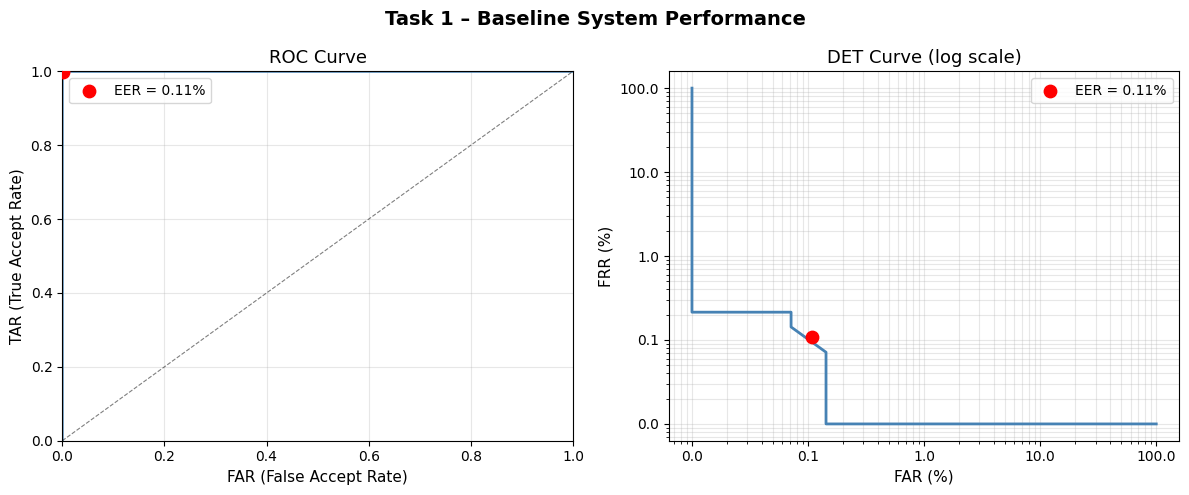

Saved: D:\pwr\biometria\lab\voice\results\task1_roc_det.png


In [7]:
thresholds = np.linspace(
    min(genuine_scores.min(), impostor_scores.min()),
    max(genuine_scores.max(), impostor_scores.max()),
    num=1000,
)
far_arr = np.array([np.mean(impostor_scores >= t) for t in thresholds])
tar_arr = np.array([np.mean(genuine_scores  >= t) for t in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC ---
ax = axes[0]
ax.plot(far_arr, tar_arr, color="steelblue", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)
ax.scatter([eer], [1 - eer], color="red", zorder=5, s=80,
           label=f"EER = {eer*100:.2f}%")
ax.set_xlabel("FAR (False Accept Rate)", fontsize=11)
ax.set_ylabel("TAR (True Accept Rate)", fontsize=11)
ax.set_title("ROC Curve", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# --- DET (log scale) ---
frr_arr = 1 - tar_arr
# Clip to avoid log(0)
eps = 1e-4
far_plot = np.clip(far_arr, eps, 1 - eps)
frr_plot = np.clip(frr_arr, eps, 1 - eps)

ax = axes[1]
ax.plot(far_plot * 100, frr_plot * 100, color="steelblue", linewidth=2)
ax.scatter([eer * 100], [eer * 100], color="red", zorder=5, s=80,
           label=f"EER = {eer*100:.2f}%")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("FAR (%)", fontsize=11)
ax.set_ylabel("FRR (%)", fontsize=11)
ax.set_title("DET Curve (log scale)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))

fig.suptitle("Task 1 – Baseline System Performance", fontsize=14, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task1_roc_det.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 7. FAR / FRR vs. threshold

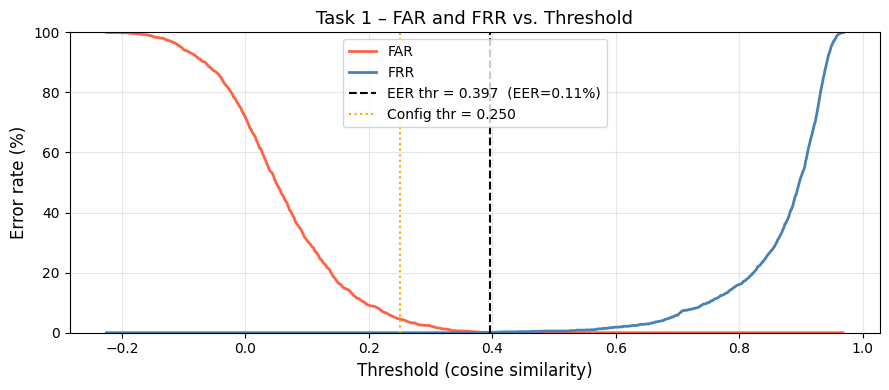

Saved: D:\pwr\biometria\lab\voice\results\task1_far_frr.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(thresholds, far_arr * 100, label="FAR", color="tomato",    linewidth=2)
ax.plot(thresholds, frr_arr * 100, label="FRR", color="steelblue", linewidth=2)

ax.axvline(eer_threshold, color="black",  linestyle="--", linewidth=1.5,
           label=f"EER thr = {eer_threshold:.3f}  (EER={eer*100:.2f}%)")
ax.axvline(config_thr,   color="orange", linestyle=":",  linewidth=1.5,
           label=f"Config thr = {config_thr:.3f}")

ax.set_xlabel("Threshold (cosine similarity)", fontsize=12)
ax.set_ylabel("Error rate (%)", fontsize=12)
ax.set_title("Task 1 – FAR and FRR vs. Threshold", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
fig.tight_layout()

out = RESULTS_DIR / "task1_far_frr.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 8. Summary table

In [10]:
import json

summary = {
    "task": 1,
    "description": "Baseline – unmodified test samples",
    "n_genuine":           int(len(genuine_scores)),
    "n_impostor":          int(len(impostor_scores)),
    "eer_pct":             round(eer * 100, 4),
    "eer_threshold":       round(float(eer_threshold), 6),
    "far_at_eer_pct":      round(metrics["far"] * 100, 4),
    "frr_at_eer_pct":      round(metrics["frr"] * 100, 4),
    "tar_at_eer_pct":      round(metrics["tar"] * 100, 4),
    "accuracy_at_eer_pct": round(metrics["accuracy"] * 100, 4),
    "genuine_mean_score":  round(float(genuine_scores.mean()),  4),
    "impostor_mean_score": round(float(impostor_scores.mean()), 4),
}

# Save JSON for later comparison with tasks 2-7
out_json = RESULTS_DIR / "task1_results.json"
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)

# Pretty print
print("═" * 24)
print("  TASK 1 – BASELINE RESULTS")
print("═" * 24)
for k, v in summary.items():
    print(f"  {k:<28} {v}")
print("═" * 24)
print(f"\nJSON saved: {out_json}")

════════════════════════
  TASK 1 – BASELINE RESULTS
════════════════════════
  task                         1
  description                  Baseline – unmodified test samples
  n_genuine                    1400
  n_impostor                   1400
  eer_pct                      0.1071
  eer_threshold                0.396871
  far_at_eer_pct               0.1429
  frr_at_eer_pct               0.0714
  tar_at_eer_pct               99.9286
  accuracy_at_eer_pct          99.8929
  genuine_mean_score           0.8697
  impostor_mean_score          0.0583
════════════════════════

JSON saved: D:\pwr\biometria\lab\voice\results\task1_results.json
